## Problema 2: Terapia con protones

## Rango CSDA

In [88]:
import numpy as np
def bethe_bloch(E_MeV):
    
    mp=938.272
    me=0.511
    K=0.307075 
    Z_A=0.5551
    rho=1.0
    I=75e-6       # propiedades del agua
    gamma = 1 + E_MeV/mp
    beta2 = 1 - 1/gamma**2
    Tmax  = (2*me*beta2*gamma**2)/(1+2*gamma*me/mp+(me/mp)**2)
    arg   = 2*me*beta2*gamma**2*Tmax/I**2
    if arg<=1 or beta2<=0: return 0.0
    return max(K*rho*Z_A/beta2*(0.5*np.log(arg)-beta2), 0.0)


def calcular_rango(E0):
    
    energias = np.linspace(0.05, E0, 5000)

    dedx_vals = np.array([bethe_bloch(e) for e in energias])

    rango = np.trapz(1/ dedx_vals, energias)
    return rango


E0_valores = [50, 150, 250]

for E in E0_valores:
    rango = calcular_rango(E)
    print(f"Rango CSDA para {E} MeV: {rango:.3f} g/cm^2")


Rango CSDA para 50 MeV: 2.222 g/cm^2
Rango CSDA para 150 MeV: 15.767 g/cm^2
Rango CSDA para 250 MeV: 37.931 g/cm^2


 ## Simulación de transporte de protones sin straggling y dosis depositada

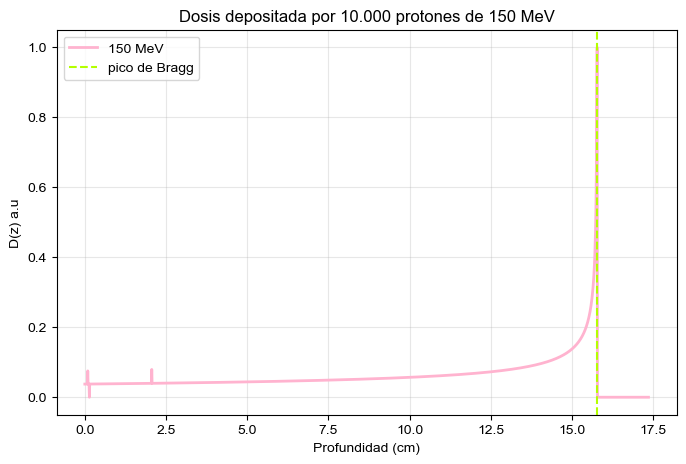

profundidad del pico de bragg [cm]: 15.775


In [89]:

import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"]
})

def transporte(E0_MeV, dx_cm=0.01):
    E = E0_MeV
    x = 0.0
    track = [(x, E)]
    
    while E > 0.5:
        dEdx_val = bethe_bloch(E)
        if dEdx_val <= 0: break
        dE = max(dEdx_val * dx_cm, 0)
        E = max(E - dE, 0)
        x += dx_cm
        track.append((x, E))
    return np.array(track)


E0 = 150
N_prot = 10000
dx = 0.01

# Cálculo de la dosis
track_ejemplo = transporte(E0, dx)
x_bins = np.arange(0, track_ejemplo[-1, 0] * 1.1, dx)
dosis = np.zeros(len(x_bins) - 1)

for _ in range(N_prot):
    track = transporte(E0, dx)
    for j in range(len(track) - 1):
        x_pos = track[j, 0]
        E_dep = track[j, 1] - track[j+1, 1]
        idx = int(x_pos / dx)
        if 0 <= idx < len(dosis):
            dosis[idx] += max(E_dep, 0)

x_centros = 0.5 * (x_bins[:-1] + x_bins[1:])
dosis_norm = dosis / dosis.max()

idx_bragg = np.argmax(dosis_norm) 
profundidad_bragg = x_centros[idx_bragg]



plt.figure(figsize=(8, 5))
plt.plot(x_centros, dosis_norm, color='#FFB3CF', lw=2, label='150 MeV')
plt.title(f'Dosis depositada por 10.000 protones de {E0} MeV')
plt.xlabel('Profundidad (cm)')
plt.axvline(x=profundidad_bragg, linestyle='--', color='#B4FF00', label ='pico de Bragg')

plt.ylabel('D(z) a.u')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print ('profundidad del pico de bragg [cm]:',profundidad_bragg)

## Simulación con straggling
$$\sigma_E^2 = 4 \pi r_e^2 (m_e c^2)^2 N_e \frac{z^2}{\beta^2} \Delta x$$
$$4 \pi r_e^2 (m_e c^2)^2 \approx 2.6 \times 10^{-25} \text{ MeV}^2 \text{ cm}^2$$
$$N_e = \rho \cdot N_A \cdot \frac{Z}{A}$$
para el agua y $\Delta x= 0.1 $mm:
$$\sigma_E^2 \approx (2.6 \times 10^{-25}) \cdot (3.34 \times 10^{23} \text{ cm}^{-3}) \cdot \frac{1}{\beta^2} \cdot (0.01 \text{ cm})$$
$$\sigma_E^2 \approx \frac{8.68 \times 10^{-4}}{\beta^2} \text{ MeV}^2$$
para un protón con $E_0= 150 MeV$ se tiene
$$\beta^2 \approx 0.25$$ $$\sigma_E^2 \approx \frac{8.68 \times 10^{-4}}{0.25} \approx 0.00347 \text{ MeV}^2 $$ $$\sigma_E =
\sqrt{0.00347} \approx \mathbf{0.059 \text{ MeV}}$$

El ensanchamiento del rango (sigma_R) es: 0.0837 cm


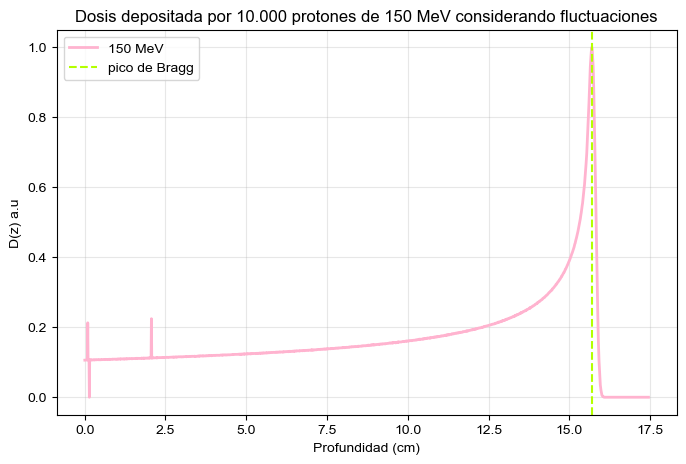

profundidad del pico de bragg [cm]: 15.695


In [93]:
def transporte(E0_MeV, dx_cm=0.01, sigma_strag=0.059):
    E = E0_MeV
    x = 0.0
    track = [(x, E)]
    
    while E > 0.5:
        dEdx_val = bethe_bloch(E)
        
        if dEdx_val <= 0: break
        dE_medio = dEdx_val * dx_cm
    
        fluctuacion = np.random.normal(0, sigma_strag * np.sqrt(dE_medio))
        dE = max(dE_medio + fluctuacion, 0) 
    
        E  = max(E - dE, 0)
        x += dx_cm
        track.append((x, E))

    return np.array(track)

E0 = 150
N_prot = 10000
dx = 0.01

track_ejemplo = transporte(E0, dx)
x_bins = np.arange(0, track_ejemplo[-1, 0] * 1.1, dx)
dosis = np.zeros(len(x_bins) - 1)
posiciones_finales = []

for _ in range(N_prot):
    
    track = transporte(E0, dx)
    rango_individuo = track[-1, 0]
    posiciones_finales.append(rango_individuo)
    for j in range(len(track) - 1):
        x_pos = track[j, 0]
        E_dep = track[j, 1] - track[j+1, 1]
        idx = int(x_pos / dx)
        if 0 <= idx < len(dosis):
            dosis[idx] += max(E_dep, 0)

x_centros = 0.5 * (x_bins[:-1] + x_bins[1:])
dosis_norm = dosis / dosis.max()
posiciones_finales = np.array(posiciones_finales)
idx_bragg = np.argmax(dosis_norm) 
profundidad_bragg = x_centros[idx_bragg]

sigma_R = np.std(posiciones_finales)
print(f"El ensanchamiento del rango (sigma_R) es: {sigma_R:.4f} cm")

plt.figure(figsize=(8, 5))
plt.plot(x_centros, dosis_norm, color='#FFB3CF', lw=2, label='150 MeV')
plt.title(f'Dosis depositada por 10.000 protones de {E0} MeV considerando fluctuaciones')
plt.xlabel('Profundidad (cm)')
plt.axvline(x=profundidad_bragg, linestyle='--', color='#B4FF00', label ='pico de Bragg')

plt.ylabel('D(z) a.u')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print ('profundidad del pico de bragg [cm]:',profundidad_bragg)
